In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import matplotlib.cm as cm
import os

In [20]:
def plot_avg_obj_func(data_folder="./output"):
    all_dfs = []

    # --- Load all CSVs and tag with algorithm name ---
    for folder_name in sorted(os.listdir(data_folder)):
        folder_path = os.path.join(data_folder, folder_name)
        if os.path.isdir(folder_path):
            for file_name in sorted(f for f in os.listdir(folder_path) if f.endswith('.csv')):
                file_path = os.path.join(folder_path, file_name)

                df = pd.read_csv(file_path)
                df['algorithm'] = folder_name
                all_dfs.append(df)

    # Concatenate into one dataframe
    df = pd.concat(all_dfs, ignore_index=True)

    # Unique nreq values → one plot per nreq
    unique_nreqs = sorted(df['nreq'].unique())
    n_plots = len(unique_nreqs)
    n_cols = 2
    n_rows = math.ceil(n_plots / n_cols)

    sns.set(style="whitegrid")
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), squeeze=False)

    # Colors per algorithm (automatic)
    algorithms = sorted(df['algorithm'].unique())
    palette = sns.color_palette("tab10", len(algorithms))
    algo_colors = dict(zip(algorithms, palette))

    # ---- Build plots ----
    for idx, nreq in enumerate(unique_nreqs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        sub = df[df['nreq'] == nreq].copy()

        ax.set_title(f"nreq = {nreq}")
        ax.set_xlabel("number")
        ax.set_ylabel("avg_obj_func")

        # Draw one curve per algorithm
        for algo in algorithms:
            df_algo = sub[sub['algorithm'] == algo]

            if df_algo.empty:
                continue

            df_algo = df_algo.sort_values("number")

            ax.plot(
                df_algo["number"],
                df_algo["avg_obj_func"],
                marker=".",
                label=algo,
                color=algo_colors[algo]
            )

        ax.legend()

    # Remove unused axes
    for idx in range(n_plots, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        fig.delaxes(axes[row][col])

    plt.tight_layout()
    plt.show()
    

In [21]:
dfs = []

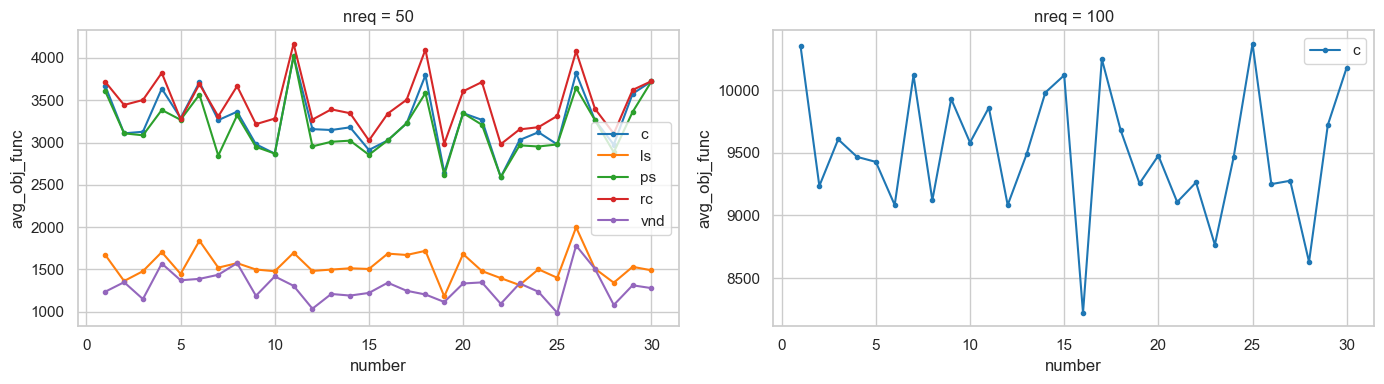

In [22]:
plot_avg_obj_func(data_folder="./output")